<a href="https://colab.research.google.com/github/LielUziahu/Stylophora-pistillata-FPs/blob/main/Spat_size_by_morph.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Spat size by morph in ambient conditions


Number of PF samples removed: 35
Number of samples removed due to missing 'area mm^2' or 'morph' values: 0
Number of samples removed where 'area mm^2' was above 10: 1

Initial number of samples: 172
Remaining samples after cleaning and outlier removal: 136

Descriptive statistics for 'area mm^2':
count    136.000000
mean       2.510471
std        1.364091
min        0.521000
25%        1.555000
50%        2.176000
75%        3.276250
max        6.021000
Name: area mm^2, dtype: float64

T-test results (HF vs NF):
  T-statistic: 0.6410
  P-value: 0.5226


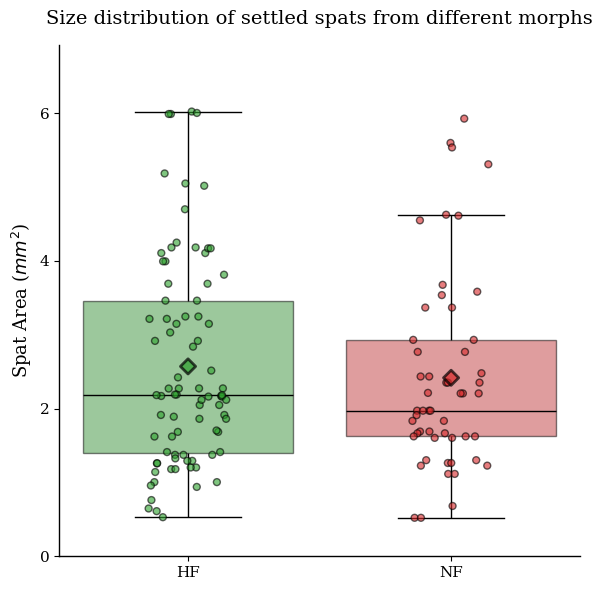

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from IPython.display import display

# ==========================================
# 1. SETUP & DATA LOADING
# ==========================================
filename = 'Ambient_Assay.csv'
# Using read_csv since the provided file is a CSV
df = pd.read_csv(filename)

# Store initial number of samples
initial_samples = len(df)

# 2. FILTERING
# (Optional) List samples to exclude if necessary, currently commented out
# samples_to_exclude = ['sample_id_1', 'sample_id_2']
# df = df[~df['SampleCode'].isin(samples_to_exclude)].copy()

# 3. CLEANING
# Clean whitespace from string columns
df['morph'] = df['morph'].str.strip()
df['SampleCode'] = df['SampleCode'].str.strip()

# Remove 'PF' morphs as requested
removed_pf = len(df[df['morph'] == 'PF'])
df = df[df['morph'] != 'PF'].copy()
print(f"Number of PF samples removed: {removed_pf}")

# Store number of samples before dropping missing values
samples_before_dropna = len(df)

# Drop rows where Area or Morph is missing
df = df.dropna(subset=['area mm^2', 'morph'])

# Calculate and print samples removed due to missing values
removed_missing = samples_before_dropna - len(df)
print(f"Number of samples removed due to missing 'area mm^2' or 'morph' values: {removed_missing}")

# Remove values where 'area mm^2' is above 10
removed_above_10 = len(df[df['area mm^2'] > 10])
df = df[df['area mm^2'] <= 10].copy()
print(f"Number of samples removed where 'area mm^2' was above 10: {removed_above_10}")

# Store DataFrame before outlier removal to identify removed samples
df_before_outlier_removal = df.copy()

# Remove outliers based on 1.5 IQR rule for 'area mm^2'
# Q1 = df['area mm^2'].quantile(0.25)
# Q3 = df['area mm^2'].quantile(0.75)
# IQR = Q3 - Q1
# lower_bound = Q1 - 1.5 * IQR
# upper_bound = Q3 + 1.5 * IQR
# df = df[(df['area mm^2'] >= lower_bound) & (df['area mm^2'] <= upper_bound)].copy()

# Calculate and print samples removed due to outlier filtering
# removed_outliers = len(df_before_outlier_removal) - len(df)
# print(f"Number of samples removed after 1.5 IQR outlier filtering: {removed_outliers}")

# Identify and print details of removed outliers
# removed_samples_df = df_before_outlier_removal[~df_before_outlier_removal.index.isin(df.index)]
# if not removed_samples_df.empty:
#     print("\nDetails of samples removed due to 1.5 IQR outlier filtering:")
#     display(removed_samples_df[['SampleCode', 'area mm^2', 'morph']])
# else:
#     print("\nNo samples were removed due to 1.5 IQR outlier filtering.")


# ==========================================
# 4. STATISTICS
# ==========================================
print(f"\nInitial number of samples: {initial_samples}")
print(f"Remaining samples after cleaning and outlier removal: {len(df)}")

# Print descriptive statistics for 'area mm^2'
print("\nDescriptive statistics for 'area mm^2':")
print(df['area mm^2'].describe())

# Extract groups
hf_area = df[df['morph'] == 'HF']['area mm^2']
nf_area = df[df['morph'] == 'NF']['area mm^2']
# pf_area = df[df['morph'] == 'PF']['area mm^2'] # PF is removed, so this line is no longer relevant for calculation

# Calculate P-value (comparing HF vs NF to match previous guideline logic)
# If you want an ANOVA across all 3, use: stats.f_oneway(hf_area, nf_area, pf_area)
t_stat, p_val = stats.ttest_ind(hf_area, nf_area)

# Print t-test results
print(f"\nT-test results (HF vs NF):\n  T-statistic: {t_stat:.4f}\n  P-value: {p_val:.4f}")

# 5. STYLING
plt.rcParams.update(
    {
        'font.family': 'serif',
        'axes.edgecolor': 'black',
        'axes.linewidth': 1,
        'xtick.color': 'black',
        'ytick.color': 'black',
        'text.color': 'black',
        'axes.labelcolor': 'black',
        'legend.frameon': False,
        'ytick.labelsize': 11,
        'xtick.labelsize': 11,
    }
)

# Define colors (PF is removed, so its color is no longer needed in the variant_colors, but keeping it for consistency if it's used elsewhere)
# HF=Green, NF=Red
variant_colors = {'HF': '#2ca02c', 'NF': '#d62728'}
morph_order = ['HF', 'NF'] # Logical order: High, None (PF removed)

plt.figure(figsize=(6, 6))

# Box Plot
ax = sns.boxplot(
    data=df,
    x='morph',
    y='area mm^2',
    order=morph_order,
    hue='morph',
    palette=variant_colors,
    width=0.8,
    showfliers=False,
    linewidth=1,
    legend=False,
    boxprops=dict(edgecolor='black', alpha=0.5),
    whiskerprops=dict(color='black'),
    capprops=dict(color='black'),
    medianprops=dict(color='black'),
)

# Jitter Points
sns.stripplot(
    data=df,
    x='morph',
    y='area mm^2',
    order=morph_order,
    hue='morph',
    palette=variant_colors,
    jitter=0.15,
    size=5,
    linewidth=1,
    edgecolor='black',
    alpha=0.6,
    legend=False,
    zorder=3,
)

# Mean Diamond
means = df.groupby('morph')['area mm^2'].mean().reindex(morph_order)
mean_colors = [variant_colors[m] for m in morph_order]
# scatter x-range must match the number of morphs (0, 1)
plt.scatter(
    range(len(morph_order)),
    means,
    c=mean_colors,
    marker='D',
    s=60,
    edgecolors='black',
    linewidths=2,
    alpha=0.7,
    zorder=4,
)

# 6. ANNOTATIONS (P-value only)
# UPDATE THESE manually based on your actual post-hoc stats results
# letters_map = {'HF': 'a', 'NF': 'b'}
# y_offset_percent = 0.05

max_val_global = df['area mm^2'].max()

# for i, m in enumerate(morph_order):
#     if m in df['morph'].unique(): # Only plot if morph exists in data
#         subset = df[df['morph'] == m]['area mm^2']
#         highest_point = subset.max()

#         # Add offset
#         pos_y = highest_point + (max_val_global * y_offset_percent)

#         letter = letters_map.get(m, "")
#         plt.text(x=i, y=pos_y, s=letter, ha='center', va='bottom', size=12, weight='bold')

# P-value (Bottom Right)
# Note: This P-value reflects the HF vs NF comparison calculated above
# p_text = f"p(HF vs NF) = {p_val:.4f}" if p_val >= 0.0001 else "p(HF vs NF) < 0.0001"
# plt.text(
#     0.95,
#     0.02,
#     s=p_text,
#     transform=ax.transAxes,
#     ha='right',
#     va='bottom',
#     size=10,
#     style='italic',
#     color='black',
# )

# 7. LABELS & TITLE
plt.ylabel("Spat Area ($mm^2$)", size=13)
plt.xlabel("") # Hide X label as categories are self-explanatory
plt.title("Size distribution of settled spats from different morphs", size=14, pad=15)

# Adjust Y limit to fit annotations
plt.ylim(0, max_val_global * 1.15)
# Optional: Set specific ticks if needed
plt.yticks(np.arange(0, max_val_global, 2))

sns.despine()
plt.tight_layout()

# 8. SAVING
plt.savefig("Spat_Size_by_morph.pdf", dpi=600)
#plt.savefig("Spat_Size_by_morph.tiff", dpi=600)
#plt.savefig("Spat_Size_by_morph_transparent.svg", transparent=True)
#plt.savefig("Spat_Size_by_morph_white_bg.svg", facecolor='white')
plt.savefig("Spat_Size_by_morph.png", dpi=600)

plt.show()

Spat size by morph in light

Number of PF samples removed: 47
Number of samples removed after 1.5 IQR outlier filtering: 4

Details of samples removed due to 1.5 IQR outlier filtering:


,SampleCode,Size,morph
91,plate2_4b,10.467,HF
152,plateC_HF_50m_7,11.061,HF
155,plateC_HF_50m_8,9.367,HF
163,plateD_NF_50m_7,8.495,NF


=== Two-Way ANOVA Results (Size) ===
                            sum_sq     df         F    PR(>F)
C(morph)                  1.914229    1.0  0.921185  0.338488
C(LightDepth)            19.138013    2.0  4.604897  0.011245
C(morph):C(LightDepth)    4.476454    2.0  1.077103  0.342828
Residual                363.651139  175.0       NaN       NaN

=== Tukey's HSD Post-hoc Test Results ===
 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
 group1  group2 meandiff p-adj   lower  upper  reject
-----------------------------------------------------
 HF_10m  HF_50m   0.6104 0.6058 -0.4954 1.7163  False
 HF_10m HF_Dark   1.2245  0.119  -0.166 2.6149  False
 HF_10m  NF_10m  -0.1541 0.9904 -0.8845 0.5763  False
 HF_10m  NF_50m   0.7799 0.6378 -0.6778 2.2377  False
 HF_10m NF_Dark   0.1515 0.9997 -1.3063 1.6092  False
 HF_50m HF_Dark   0.6141 0.8931 -1.0414 2.2695  False
 HF_50m  NF_10m  -0.7645  0.404 -1.9223 0.3933  False
 HF_50m  NF_50m   0.1695 0.9997 -1.5428 1.8819  False
 HF_50m NF_Dark 

/tmp/ipython-input-74417173.py:186: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  patch = mpatches.Patch(color=variant_colors[morph], label=morph, edgecolor='black', linewidth=1, alpha=0.6)


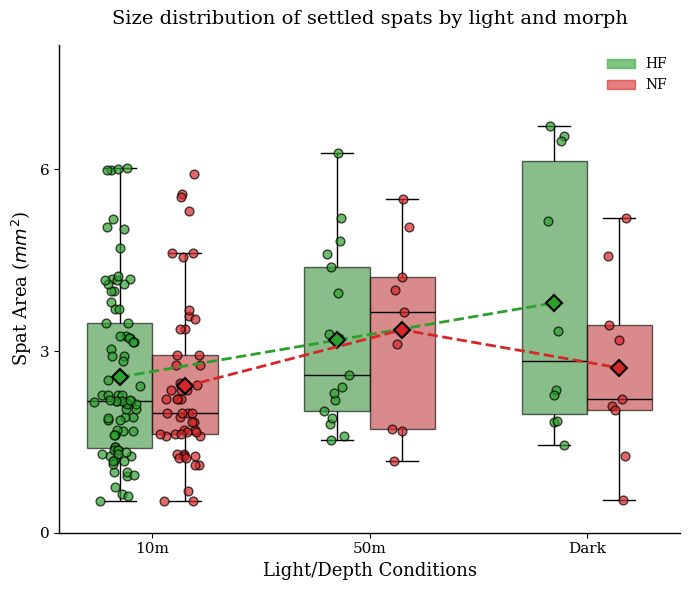

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
import matplotlib.ticker as ticker
import matplotlib.patches as mpatches
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from IPython.display import display

# ==========================================
# 1. SETUP & DATA LOADING
# ==========================================
filename = "Light_Assay.csv"
df = pd.read_csv(filename)

# --- Handle 'morph' and 'color' columns consistently ---
# The file has 'color' column for morphs (HF/NF/PF)
if 'color' in df.columns:
    # Rename 'color' to 'morph'
    df = df.rename(columns={'color': 'morph'})

# Drop rows with missing values in critical columns
df = df.dropna(subset=['area mm^2', 'morph', 'LightDepth'])

# --- FILTERING ---
# 1. Remove PF (Partial Fluorescence)
removed_pf = len(df[df['morph'] == 'PF'])
df = df[df['morph'] != 'PF'].copy()
print(f"Number of PF samples removed: {removed_pf}")

# 2. Rename Target Variable
# Rename 'area mm^2' to 'Size' to match the script logic
df = df.rename(columns={"area mm^2": "Size"})

# Clean 'morph' strings
df['morph'] = df['morph'].str.strip()

# Clean and Order the LightDepth column
# Logic: High Light (10m) -> Low Light (50m) -> No Light (Dark)
df["LightDepth"] = df["LightDepth"].astype(str).str.strip()
light_order = ["10m", "50m", "Dark"]
df["LightDepth"] = pd.Categorical(df["LightDepth"], categories=light_order, ordered=True)

# Drop rows with unexpected LightDepth values
df = df[df["LightDepth"].isin(light_order)].copy()
df = df.reset_index(drop=True)

# Store DataFrame before outlier removal to identify removed samples
df_before_outlier_removal = df.copy()

# Remove outliers based on 1.5 IQR rule for 'Size'
Q1 = df['Size'].quantile(0.25)
Q3 = df['Size'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df = df[(df['Size'] >= lower_bound) & (df['Size'] <= upper_bound)].copy()

# Calculate and print samples removed due to outlier filtering
removed_outliers = len(df_before_outlier_removal) - len(df)
print(f"Number of samples removed after 1.5 IQR outlier filtering: {removed_outliers}")

# Identify and display details of removed outliers
removed_samples_df_Light = df_before_outlier_removal[~df_before_outlier_removal.index.isin(df.index)]
if not removed_samples_df_Light.empty:
    print("\nDetails of samples removed due to 1.5 IQR outlier filtering:")
    display(removed_samples_df_Light[['SampleCode', 'Size', 'morph']])
else:
    print("\nNo samples were removed due to 1.5 IQR outlier filtering.")

# ==========================================
# 2. STATISTICS (Two-Way ANOVA & Tukey's HSD)
# ==========================================
print("=== Two-Way ANOVA Results (Size) ===")
# Model: Size depends on morph and LightDepth
model = ols("Size ~ C(morph) + C(LightDepth) + C(morph):C(LightDepth)", data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

# 2.1 Tukey's HSD Post-hoc Test
df['group'] = df['morph'].astype(str) + "_" + df['LightDepth'].astype(str)
tukey_result = pairwise_tukeyhsd(endog=df['Size'], groups=df['group'], alpha=0.05)

print("\n=== Tukey's HSD Post-hoc Test Results ===")
print(tukey_result)

# ==========================================
# 3. STYLING SETUP
# ==========================================
plt.rcParams.update({
    "font.family": "serif",
    "axes.edgecolor": "black", "axes.linewidth": 1,
    "xtick.color": "black", "ytick.color": "black",
    "text.color": "black", "axes.labelcolor": "black",
    "legend.frameon": False,
    "ytick.labelsize": 11,
    "xtick.labelsize": 11
})

# Colors matching the previous file
variant_colors = {"HF": "#2ca02c", "NF": "#d62728"}
morph_order = ["HF", "NF"]

fig, ax = plt.subplots(figsize=(7, 6))

# ==========================================
# 4. PLOT CONSTRUCTION
# ==========================================
box_width = 0.6
offset = box_width / 4

x_positions = {
    "HF": -offset,
    "NF": +offset
}

# Variable to plot on X-axis
x_col = "LightDepth"
x_order = light_order

for morph in morph_order:
    sub = df[df["morph"] == morph]
    if sub.empty: continue

    # A. Boxplots
    sns.boxplot(
        data=sub, x=x_col, y="Size",
        order=x_order,
        width=box_width / 2,
        color=variant_colors[morph],
        showfliers=False, linewidth=1,
        boxprops=dict(edgecolor="black", alpha=0.6),
        whiskerprops=dict(color="black"),
        capprops=dict(color="black"),
        medianprops=dict(color="black"),
        ax=ax,
        positions=np.arange(len(x_order)) + x_positions[morph]
    )

    # B. Jittered points
    for i, level in enumerate(x_order):
        y = sub[sub[x_col] == level]["Size"]
        if len(y) > 0:
            # Add random jitter to x
            x_vals = np.random.normal(i + x_positions[morph], 0.04, size=len(y))

            ax.scatter(
                x_vals, y,
                s=40, c=variant_colors[morph],
                edgecolors="black", linewidths=1,
                alpha=0.7, zorder=3
            )

    # C. Mean Diamonds
    means = sub.groupby(x_col, observed=False)["Size"].mean().reindex(x_order)

    # Handle potential missing data for lines
    valid_indices = ~means.isna()
    if valid_indices.any():
        ax.plot(
            np.arange(len(x_order))[valid_indices] + x_positions[morph],
            means[valid_indices],
            marker="D", linestyle="--",
            markersize=8,
            markerfacecolor=variant_colors[morph],
            markeredgecolor="black",
            markeredgewidth=1.5,
            linewidth=2,
            color=variant_colors[morph],
            zorder=4
        )

# ==========================================
# 5. LABELS, LEGEND & ANNOTATION
# ==========================================
ax.set_ylabel("Spat Area ($mm^2$)", fontsize=13)
ax.set_xlabel("Light/Depth Conditions", fontsize=13)
ax.set_title("Size distribution of settled spats by light and morph", fontsize=14, pad=15)

# Custom Legend
legend_handles = []
for morph in morph_order:
    patch = mpatches.Patch(color=variant_colors[morph], label=morph, edgecolor='black', linewidth=1, alpha=0.6)
    legend_handles.append(patch)
ax.legend(handles=legend_handles, labels=morph_order, title=None, frameon=False, loc="upper right")

# Fix X-axis ticks
ax.set_xticks(np.arange(len(x_order)))
ax.set_xticklabels(x_order)

# Y-axis formatting
max_val = df["Size"].max()
ax.set_ylim(0, max_val * 1.2)
# Adjusted tick frequency to 0.5 for size data (since values are smaller than respiration)
ax.yaxis.set_major_locator(ticker.MultipleLocator(3)) # Changed from 0.5 to 3

sns.despine(ax=ax)
fig.tight_layout()

# Save options
plt.savefig("Size_by_Light_Morph_Style.png", dpi=600)
#plt.savefig("Size_by_Light_Morph_Style.pdf", dpi=600)
#plt.savefig("Size_by_Light_Morph_Style.tiff", dpi=600) # Added TIFF save option
#plt.savefig("Size_by_Light_Morph_Style_transparent.svg", transparent=True) # Added SVG transparent save option
#plt.savefig("Size_by_Light_Morph_Style_white_bg.svg", facecolor='white') # Added SVG white background save option
plt.show()


spat size by morph and pH

Number of samples removed after 1.5 IQR outlier filtering: 8

Details of samples removed due to 1.5 IQR outlier filtering:


,SampleCode,Size,morph
161,plateA_HF_27C_2,6.021,HF
180,plateC_HF_8.2_12,5.988,HF
184,plateA_HF_27C_7,6.002,HF
189,plate2_4b,10.467,HF
195,plateC_HF_8.2_12,5.988,HF
213,plate1_9b,5.596,NF
241,plate1_9a,5.535,NF
248,plate2_96d,5.925,NF


=== Two-Way ANOVA Results (Size) ===


,sum_sq,df,F,PR(>F)
C(morph),0.044578,1.0,0.041389,0.838986
C(pH),3.376156,2.0,1.567307,0.211025
C(morph):C(pH),3.357110,2.0,1.558466,0.212871
Residual,227.258858,211.0,NaN,NaN



=== Tukey's HSD Post-hoc Test Results ===
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
HF_7.6 HF_7.8  -0.3519 0.8018 -1.1496 0.4459  False
HF_7.6 HF_8.2  -0.0498 0.9999 -0.7062 0.6067  False
HF_7.6 NF_7.6   0.4134 0.8283 -0.5637 1.3904  False
HF_7.6 NF_7.8   -0.073 0.9999 -0.9747 0.8288  False
HF_7.6 NF_8.2  -0.2263   0.94 -0.9309 0.4782  False
HF_7.8 HF_8.2   0.3021 0.7717 -0.3544 0.9586  False
HF_7.8 NF_7.6   0.7652 0.2186 -0.2118 1.7422  False
HF_7.8 NF_7.8   0.2789 0.9487 -0.6229 1.1806  False
HF_7.8 NF_8.2   0.1255 0.9957  -0.579 0.8301  False
HF_8.2 NF_7.6   0.4631 0.6396 -0.4024 1.3287  False
HF_8.2 NF_7.8  -0.0232    1.0 -0.8028 0.7564  False
HF_8.2 NF_8.2  -0.1766 0.9352  -0.716 0.3628  False
NF_7.6 NF_7.8  -0.4863 0.7765   -1.55 0.5773  False
NF_7.6 NF_8.2  -0.6397 0.3242 -1.5422 0.2628  False
NF_7.8 NF_8.2  -0.1534 0.9946 -0.9738 0.6671  False
---------------------

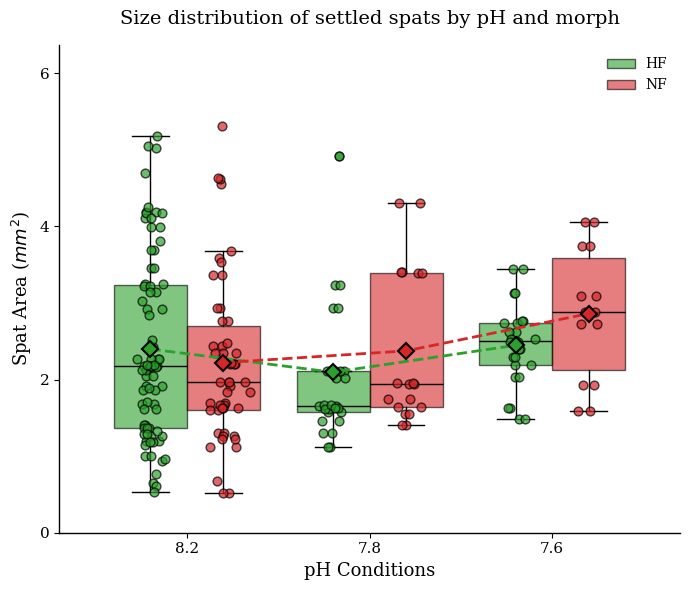

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from IPython.display import display

# ==========================================
# 1. SETUP & DATA LOADING
# ==========================================
filename = "pH_Assay.csv"
df = pd.read_csv(filename)

# Standardize columns
df.columns = df.columns.str.strip()
if 'color' in df.columns: df = df.rename(columns={'color': 'morph'})
if 'area mm^2' in df.columns: df = df.rename(columns={'area mm^2': 'Size'})
else:
    cols = [c for c in df.columns if 'area' in c.lower()]
    if cols: df = df.rename(columns={cols[0]: 'Size'})

df['morph'] = df['morph'].str.strip()
df['pH'] = df['pH'].astype(str).str.strip()

# Drop NaNs
df = df.dropna(subset=['Size', 'morph', 'pH'])

# ==========================================
# 2. FILTER & PREP FOR PLOT
# ==========================================
# Remove PF
df_plot = df[df['morph'] != 'PF'].copy()

# Order pH: 8.2 (Control) -> 7.8 -> 7.6 (Stress)
ph_order = ["8.2", "7.8", "7.6"]
# Filter to keep only these levels if they exist
df_plot = df_plot[df_plot["pH"].isin(ph_order)].copy()
df_plot["pH"] = pd.Categorical(df_plot["pH"], categories=ph_order, ordered=True)

# Store DataFrame before outlier removal to identify removed samples
df_plot_before_outlier_removal = df_plot.copy()

# Remove outliers based on 1.5 IQR rule for 'Size'
Q1 = df_plot['Size'].quantile(0.25)
Q3 = df_plot['Size'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df_plot = df_plot[(df_plot['Size'] >= lower_bound) & (df_plot['Size'] <= upper_bound)].copy()

# Calculate and print samples removed due to outlier filtering
removed_outliers_pH = len(df_plot_before_outlier_removal) - len(df_plot)
print(f"Number of samples removed after 1.5 IQR outlier filtering: {removed_outliers_pH}")

# Identify and display details of removed outliers
removed_samples_df_pH = df_plot_before_outlier_removal[~df_plot_before_outlier_removal.index.isin(df_plot.index)]
if not removed_samples_df_pH.empty:
    print("\nDetails of samples removed due to 1.5 IQR outlier filtering:")
    display(removed_samples_df_pH[['SampleCode', 'Size', 'morph']])
else:
    print("\nNo samples were removed due to 1.5 IQR outlier filtering.")

# ==========================================
# 2.1 STATISTICS (Two-Way ANOVA & Tukey's HSD) - ADDED HERE
# ==========================================
print("=== Two-Way ANOVA Results (Size) ===")
# Model: Size depends on morph and pH
model = ols("Size ~ C(morph) + C(pH) + C(morph):C(pH)", data=df_plot).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
display(anova_table) # Use display for DataFrame

# Tukey's HSD Post-hoc Test
df_plot['group'] = df_plot['morph'].astype(str) + "_" + df_plot['pH'].astype(str)
tukey_result = pairwise_tukeyhsd(endog=df_plot['Size'], groups=df_plot['group'], alpha=0.05)

print("\n=== Tukey's HSD Post-hoc Test Results ===")
print(tukey_result) # print for summary table

# ==========================================
# 3. PLOTTING
# ==========================================
plt.rcParams.update({
    "font.family": "serif",
    "axes.edgecolor": "black", "axes.linewidth": 1,
    "xtick.color": "black", "ytick.color": "black",
    "text.color": "black", "axes.labelcolor": "black",
    "legend.frameon": False,
    "ytick.labelsize": 11,
    "xtick.labelsize": 11
})

# COLORS FROM Light_size.py
variant_colors = {"HF": "#2ca02c", "NF": "#d62728"}
morph_order = ["HF", "NF"]

fig, ax = plt.subplots(figsize=(7, 6))

box_width = 0.8 # Changed to make boxes wider
offset = box_width / 4
x_positions = {"HF": -offset, "NF": +offset}

for morph in morph_order:
    sub = df_plot[df_plot["morph"] == morph]
    if sub.empty: continue

    positions = np.arange(len(ph_order)) + x_positions[morph]

    # A. Boxplots
    # Using ax.boxplot to mimic sns.boxplot style from Light_size.py
    data_to_plot = [sub[sub["pH"] == level]["Size"].values for level in ph_order]

    # Handle empty data arrays to avoid errors
    data_to_plot = [d if len(d) > 0 else np.array([]) for d in data_to_plot]

    bp = ax.boxplot(data_to_plot, positions=positions, widths=box_width/2,
                    patch_artist=True, showfliers=False)

    # Style match: alpha=0.6, black edges
    for patch in bp['boxes']:
        patch.set_facecolor(variant_colors[morph])
        patch.set_alpha(0.6) # Matched to Light_size.py alpha
        patch.set_edgecolor('black')
        patch.set_linewidth(1)

    for element in ['whiskers', 'caps', 'medians']:
        plt.setp(bp[element], color='black', linewidth=1)

    # B. Jittered Points
    for i, level in enumerate(ph_order):
        y = sub[sub["pH"] == level]["Size"]
        if len(y) > 0:
            # Jitter
            x_vals = np.random.normal(i + x_positions[morph], 0.04, size=len(y))

            ax.scatter(
                x_vals, y,
                s=40, c=variant_colors[morph],
                edgecolors="black", linewidths=1,
                alpha=0.7, zorder=3
            )

    # C. Mean Diamonds (Changed from Median Diamonds)
    means = sub.groupby("pH", observed=False)["Size"].mean().reindex(ph_order) # Changed to mean() and added observed=False
    valid = ~means.isna()
    if valid.any():
        ax.plot(
            np.arange(len(ph_order))[valid] + x_positions[morph],
            means[valid], # Changed to means
            marker="D", linestyle="--",
            markersize=8,
            markerfacecolor=variant_colors[morph],
            markeredgecolor="black",
            markeredgewidth=1.5,
            linewidth=2,
            color=variant_colors[morph],
            zorder=4
        )

# Labels & Legend
ax.set_ylabel("Spat Area ($mm^2$)", fontsize=13)
ax.set_xlabel("pH Conditions", fontsize=13)
ax.set_title("Size distribution of settled spats by pH and morph", fontsize=14, pad=15)

# Legend
handles = [mpatches.Patch(color=variant_colors[m], label=m, alpha=0.6, ec='black') for m in morph_order]
ax.legend(handles=handles, title=None, frameon=False, loc="upper right")

# Ticks
ax.set_xticks(np.arange(len(ph_order)))
ax.set_xticklabels(ph_order)

# Y-axis formatting
max_val = df_plot["Size"].max()
ax.set_ylim(0, max_val * 1.2)
ax.yaxis.set_major_locator(ticker.MultipleLocator(2.0)) # Changed to tick every 2 units

sns.despine(ax=ax)
fig.tight_layout()

plt.savefig("Size_by_pH_Morph_Style.png", dpi=600)
#plt.savefig("Size_by_pH_Morph_Style.pdf", dpi=600)
#plt.savefig("Size_by_pH_Morph_Style.tiff", dpi=600) # Added TIFF save option
#plt.savefig("Size_by_pH_Morph_Style_transparent.svg", transparent=True) # Added SVG transparent save option
#plt.savefig("Size_by_pH_Morph_Style_white_bg.svg", facecolor='white') # Added SVG white background save option
plt.show()

spat size by morph and Temp

Number of samples removed after 1.5 IQR outlier filtering: 3

Details of samples removed due to 1.5 IQR outlier filtering:


,SampleCode,Size,morph
105,plate2_4b,10.467,HF
187,plateD_NF_50m_7,8.495,NF
200,plate2_16a,8.450,HF


=== Two-Way ANOVA Results (Size) ===


,sum_sq,df,F,PR(>F)
C(morph),0.196169,1.0,0.101461,0.750416
C(Temp),8.686880,2.0,2.246480,0.108433
C(morph):C(Temp),1.830411,2.0,0.473355,0.623605
Residual,386.688431,200.0,NaN,NaN



=== Tukey's HSD Post-hoc Test Results ===
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
 HF_23  HF_27   0.3724 0.8571 -0.5549 1.2998  False
 HF_23  HF_32   0.1742  0.999 -1.1652 1.5135  False
 HF_23  NF_23  -0.1541 0.9886 -0.8576 0.5494  False
 HF_23  NF_27   0.3284 0.8942  -0.558 1.2149  False
 HF_23  NF_32   0.6846 0.7253 -0.7196 2.0888  False
 HF_27  HF_32  -0.1983  0.999 -1.7043 1.3077  False
 HF_27  NF_23  -0.5265 0.6395  -1.511 0.4579  False
 HF_27  NF_27   -0.044    1.0 -1.1665 1.0785  False
 HF_27  NF_32   0.3122 0.9926 -1.2518 1.8761  False
 HF_32  NF_23  -0.3283 0.9835 -1.7078 1.0512  False
 HF_32  NF_27   0.1543 0.9997 -1.3269 1.6354  False
 HF_32  NF_32   0.5104 0.9674  -1.328 2.3488  False
 NF_23  NF_27   0.4825 0.6852 -0.4635 1.4286  False
 NF_23  NF_32   0.8387 0.5513 -0.6039 2.2812  False
 NF_27  NF_32   0.3561 0.9855 -1.1839 1.8962  False
---------------------

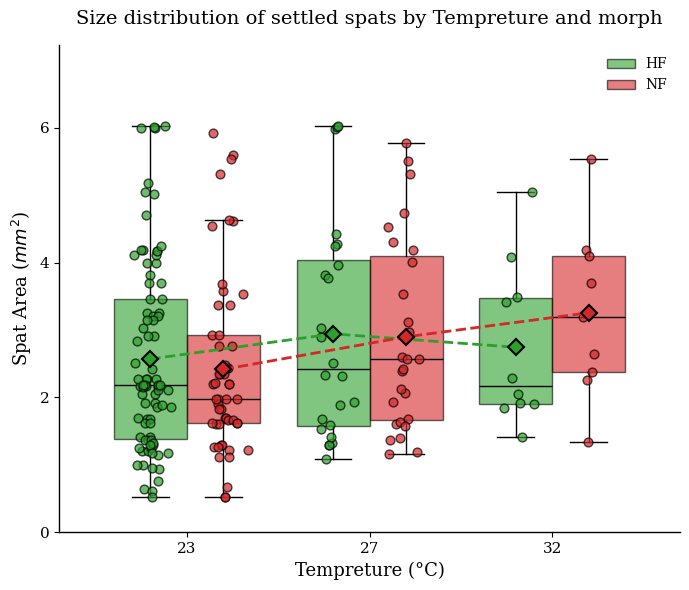

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from IPython.display import display

# ==========================================
# 1. SETUP & DATA LOADING
# ==========================================
filename = "Temp_Assay.csv"
df = pd.read_csv(filename)

# Standardize columns
df.columns = df.columns.str.strip()
if 'color' in df.columns: df = df.rename(columns={'color': 'morph'})
if 'area mm^2' in df.columns: df = df.rename(columns={'area mm^2': 'Size'})
else:
    cols = [c for c in df.columns if 'area' in c.lower()]
    if cols: df = df.rename(columns={cols[0]: 'Size'})

df['morph'] = df['morph'].str.strip()
df['Temp'] = df['temp'].astype(str).str.strip() # Fixed 'Temp' to 'temp'

# Drop NaNs
df = df.dropna(subset=['Size', 'morph', 'Temp'])

# ==========================================
# 2. FILTER & PREP FOR PLOT
# ==========================================
# Remove PF
df_plot = df[df['morph'] != 'PF'].copy()

# Order pH: 23 (Control) -> 27 -> 32 (Stress)
Temp_order = ["23", "27", "32"]
# Filter to keep only these levels if they exist
df_plot = df_plot[df_plot["Temp"].isin(Temp_order)].copy() # Fixed 'ph_order' to 'Temp_order'
df_plot["Temp"] = pd.Categorical(df_plot["Temp"], categories=Temp_order, ordered=True)

# Store DataFrame before outlier removal to identify removed samples
df_plot_before_outlier_removal = df_plot.copy()

# Remove outliers based on 1.5 IQR rule for 'Size'
Q1 = df_plot['Size'].quantile(0.25)
Q3 = df_plot['Size'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df_plot = df_plot[(df_plot['Size'] >= lower_bound) & (df_plot['Size'] <= upper_bound)].copy()

# Calculate and print samples removed due to outlier filtering
removed_outliers_Temp = len(df_plot_before_outlier_removal) - len(df_plot)
print(f"Number of samples removed after 1.5 IQR outlier filtering: {removed_outliers_Temp}")

# Identify and display details of removed outliers
removed_samples_df_Temp = df_plot_before_outlier_removal[~df_plot_before_outlier_removal.index.isin(df_plot.index)]
if not removed_samples_df_Temp.empty:
    print("\nDetails of samples removed due to 1.5 IQR outlier filtering:")
    display(removed_samples_df_Temp[['SampleCode', 'Size', 'morph']])
else:
    print("\nNo samples were removed due to 1.5 IQR outlier filtering.")

# ==========================================
# 2.1 STATISTICS (Two-Way ANOVA & Tukey's HSD) - ADDED HERE
# ==========================================
print("=== Two-Way ANOVA Results (Size) ===")
# Model: Size depends on morph and Temp
model = ols("Size ~ C(morph) + C(Temp) + C(morph):C(Temp)", data=df_plot).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
display(anova_table) # Use display for DataFrame

# Tukey's HSD Post-hoc Test
df_plot['group'] = df_plot['morph'].astype(str) + "_" + df_plot['Temp'].astype(str)
tukey_result = pairwise_tukeyhsd(endog=df_plot['Size'], groups=df_plot['group'], alpha=0.05)

print("\n=== Tukey's HSD Post-hoc Test Results ===")
print(tukey_result) # print for summary table

# ==========================================
# 3. PLOTTING
# ==========================================
plt.rcParams.update({
    "font.family": "serif",
    "axes.edgecolor": "black", "axes.linewidth": 1,
    "xtick.color": "black", "ytick.color": "black",
    "text.color": "black", "axes.labelcolor": "black",
    "legend.frameon": False,
    "ytick.labelsize": 11,
    "xtick.labelsize": 11
})

# COLORS FROM Light_size.py
variant_colors = {"HF": "#2ca02c", "NF": "#d62728"}
morph_order = ["HF", "NF"]

fig, ax = plt.subplots(figsize=(7, 6))

box_width = 0.8 # Changed to make boxes wider
offset = box_width / 4
x_positions = {"HF": -offset, "NF": +offset}

for morph in morph_order:
    sub = df_plot[df_plot["morph"] == morph]
    if sub.empty: continue

    positions = np.arange(len(Temp_order)) + x_positions[morph] # Fixed 'ph_order' to 'Temp_order'

    # A. Boxplots
    # Using ax.boxplot to mimic sns.boxplot style from Light_size.py
    data_to_plot = [sub[sub["Temp"] == level]["Size"].values for level in Temp_order]

    # Handle empty data arrays to avoid errors
    data_to_plot = [d if len(d) > 0 else np.array([]) for d in data_to_plot]

    bp = ax.boxplot(data_to_plot, positions=positions, widths=box_width/2,
                    patch_artist=True, showfliers=False)

    # Style match: alpha=0.6, black edges
    for patch in bp['boxes']:
        patch.set_facecolor(variant_colors[morph])
        patch.set_alpha(0.6) # Matched to Light_size.py alpha
        patch.set_edgecolor('black')
        patch.set_linewidth(1)

    for element in ['whiskers', 'caps', 'medians']:
        plt.setp(bp[element], color='black', linewidth=1)

    # B. Jittered Points
    for i, level in enumerate(Temp_order): # Fixed 'ph_order' to 'Temp_order'
        y = sub[sub["Temp"] == level]["Size"]
        if len(y) > 0:
            # Jitter
            x_vals = np.random.normal(i + x_positions[morph], 0.04, size=len(y))

            ax.scatter(
                x_vals, y,
                s=40, c=variant_colors[morph],
                edgecolors="black", linewidths=1,
                alpha=0.7, zorder=3
            )

    # C. Mean Diamonds (Changed from Median Diamonds)
    means = sub.groupby("Temp", observed=False)["Size"].mean().reindex(Temp_order) # Changed to mean() and added observed=False
    valid = ~means.isna()
    if valid.any():
        ax.plot(
            np.arange(len(Temp_order))[valid] + x_positions[morph], # Fixed 'ph_order' to 'Temp_order'
            means[valid], # Changed to means
            marker="D", linestyle="--",
            markersize=8,
            markerfacecolor=variant_colors[morph],
            markeredgecolor="black",
            markeredgewidth=1.5,
            linewidth=2,
            color=variant_colors[morph],
            zorder=4
        )

# Labels & Legend
plt.ylabel("Spat Area ($mm^2$)", fontsize=13)
plt.xlabel("Tempreture (°C)", fontsize=13)
plt.title("Size distribution of settled spats by Tempreture and morph", fontsize=14, pad=15)

# Legend
handles = [mpatches.Patch(color=variant_colors[m], label=m, alpha=0.6, ec='black') for m in morph_order]
ax.legend(handles=handles, title=None, frameon=False, loc="upper right")

# Ticks
ax.set_xticks(np.arange(len(Temp_order))) # Fixed 'Temph_order' to 'Temp_order'
ax.set_xticklabels(Temp_order) # Fixed 'Temph_order' to 'Temp_order'

# Y-axis formatting
max_val = df_plot["Size"].max()
ax.set_ylim(0, max_val * 1.2)
ax.yaxis.set_major_locator(ticker.MultipleLocator(2.0)) # Changed to tick every 2 units

sns.despine(ax=ax)
fig.tight_layout()

plt.savefig("Size_by_Temp_Morph_Style.png", dpi=600)
#plt.savefig("Size_by_Temp_Morph_Style.pdf", dpi=600)
#plt.savefig("Size_by_Temp_Morph_Style.tiff", dpi=600) # Added TIFF save option
#plt.savefig("Size_by_Temp_Morph_Style_transparent.svg", transparent=True) # Added SVG transparent save option
#plt.savefig("Size_by_Temp_Morph_Style_white_bg.svg", facecolor='white') # Added SVG white background save option
plt.show()